# 深度Q网络

传统的强化学习**局限**：现实中的强化学习任务所面临的状态空间往往是连续的，无法使用表格对价值函数进行存储

**价值函数近似**：用函数近似计算，$Q_\phi(s,a) \approx Q_\pi(s,a)$
  - **Q网络**：用神经网络近似价值函数

## 6.1 状态价值函数

- 深度Q网络是**基于价值**的算法，学习的不是策略，而是**评论员**

- 有一种评论员称为**状态价值函数**$V_{\pi}$：
  - 策略$\pi$ 看到状态 $s$ 的时候，预期到**回合结束**的时候，可以获得的奖励

- 训练价值网络 $V_{\pi}$
  - **蒙特卡洛**：方差较大
    - **执行整个回合**获得轨迹，计算状态 $s_a$ 的累积奖励 $G_a$ （实际值）
    - 网络预估价值 $V_{\pi}(s_a)$ （预测值）
    - 降低实际值与预测值的差距
  - **时序差分**：更常用
    - 状态 $s_t$ 采取动作 $a_t$ 得到奖励$r_t$ ，进入状态 $s_{t+1}$
    - 基于公式：$V_{\pi}\left(s_{t}\right)=V_{\pi}\left(s_{t+1}\right)+r_{t}$
    - 降低 $V_{\pi}\left(s_{t}\right)-V_{\pi}\left(s_{t+1}\right)$ 与 $r_{t}$ 的差距


## 6.2 动作价值函数

- 另外一种评论员称为**Q函数**，**动作价值函数**
  - 指在某一个状态采取某一个动作，得到的累积奖励的期望值

- Q函数有两种写法
  - 输入是状态与动作，输出就是一个标量：适用**离散和连续**动作
  - 输入是一个状态，输出就是多个值（各个动作的累积奖励）：只适用于**离散**

- 基于Q函数学习
  - $\pi^{\prime}(s)=\underset{a}{\arg \max} Q_{\pi}(s, a)$
  - $V_{\pi}(s) \leqslant Q_{\pi}\left(s, \pi^{\prime}(s)\right) \leqslant V_{\pi^{\prime}}(s)$

## 6.3 深度Q网络技巧

- **目标网络**
  - 学习Q函数：$Q_{\pi}\left(s_{t}, a_{t}\right) = r_{t}+Q_{\pi}\left(s_{t+1}, \pi\left(s_{t+1}\right)\right)$
  - 看成两个模型左边作为预测，右边作为目标，通过反向传播更新 $Q_{\pi}$ 的参数，两个模型都在变，即要去拟合的目标是一直在变动，不利于训练
  - 把右边的参数固定住（**目标网络**），让左边向右边拟合，n回合后在更新右边的参数

- **探索**
  - 策略完全取决于 Q 函数，$a=\underset{a}{\arg \max} Q(s, a)$，容易陷入局部最优，**探索-利用窘境**问题
  - $\pmb{\varepsilon}$**-贪心**
    - $1-\varepsilon$ 的概率会按照Q函数来决定动作，$\varepsilon$ 的概率随机
  - **玻尔兹曼探索（Boltzmann exploration）**
    - $\pi(a \mid s)=\frac{\mathrm{e}^{Q(s, a) / T}}{\sum_{a^{\prime} \in A} \mathrm{e}^{Q\left(s, a^{\prime}\right) / T}}$


- **经验回放**：
  - **异策略**的算法
  - 构建一个**回放缓冲区**或**回放内存**，收集数据($s_t$, $a_t$, $r_t$, $s_{t+1}$)，回放缓冲区里面的经验可能来自**不同的策略**
  - 从回放缓冲区中随机挑一个批量（batch），用来更新Q函数



## 6.4 深度Q网络一般算法

- 初始化函数$Q$、目标函数$\hat{Q}$，$\hat{Q} = Q$
- 对于每一个回合
  - 对于每一个时间步t
    - 对于给定状态 $s_t$，基于Q($\varepsilon$-贪心)执行动作 $a_t$
    - 得到奖励 $r_t$，进入状态 $s_{t+1}$
    - $(s_t$、$a_t$ 、$r_t$、$s_{t+1})$ 放到回放缓冲区
    - 从回放缓冲区采样批量数据 $(s_{i}$、$a_{i}$、$r_{i}$、$s_{i+1})$
    - 目标值 $y=r_{i}+\max _{a} \hat{Q}\left(s_{i+1}, a\right)$
    - 更新Q的参数，使得 $Q(s_i,a_i)$ 与接近 $y$
    - 每 $C$ 次更新 $\hat{Q} = Q$


- 对比PPO，更新完数据不需要清空，而是随着训练进行自动过滤历史数据（超出最大容量）
- DQN模型输出的是价值（价值迭代），PPO输出动作概率（策略迭代）


开始训练！
环境：CartPole-v1, 算法：DQN, 设备：cuda
回合：10/200，奖励：43.00，Epislon：0.853
回合：20/200，奖励：15.00，Epislon：0.795
回合：30/200，奖励：16.00，Epislon：0.721
回合：40/200，奖励：12.00，Epislon：0.673
回合：50/200，奖励：10.00，Epislon：0.629
回合：60/200，奖励：17.00，Epislon：0.589
回合：70/200，奖励：15.00，Epislon：0.541
回合：80/200，奖励：28.00，Epislon：0.503
回合：90/200，奖励：88.00，Epislon：0.395
回合：100/200，奖励：136.00，Epislon：0.236
回合：110/200，奖励：322.00，Epislon：0.105
回合：120/200，奖励：249.00，Epislon：0.034
回合：130/200，奖励：500.00，Epislon：0.015
回合：140/200，奖励：272.00，Epislon：0.011
回合：150/200，奖励：464.00，Epislon：0.010
回合：160/200，奖励：426.00，Epislon：0.010
回合：170/200，奖励：500.00，Epislon：0.010
回合：180/200，奖励：500.00，Epislon：0.010
回合：190/200，奖励：500.00，Epislon：0.010
回合：200/200，奖励：500.00，Epislon：0.010
完成训练！


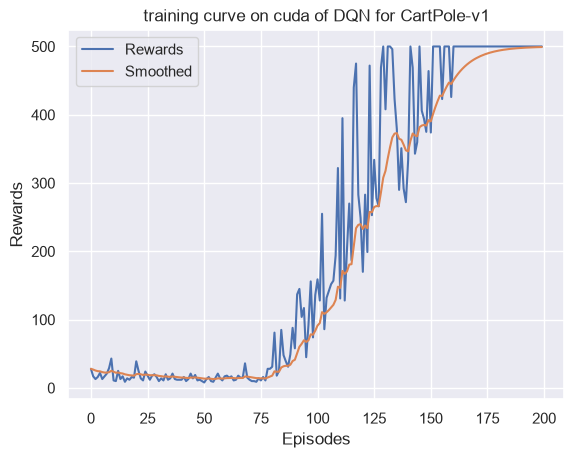

开始测试！
环境：CartPole-v1, 算法：DQN, 设备：cuda
回合数：1/20, 奖励：500.0
回合数：2/20, 奖励：500.0
回合数：3/20, 奖励：500.0
回合数：4/20, 奖励：500.0
回合数：5/20, 奖励：500.0
回合数：6/20, 奖励：500.0
回合数：7/20, 奖励：500.0
回合数：8/20, 奖励：500.0
回合数：9/20, 奖励：500.0
回合数：10/20, 奖励：500.0
回合数：11/20, 奖励：500.0
回合数：12/20, 奖励：500.0
回合数：13/20, 奖励：500.0
回合数：14/20, 奖励：500.0
回合数：15/20, 奖励：500.0
回合数：16/20, 奖励：500.0
回合数：17/20, 奖励：500.0
回合数：18/20, 奖励：500.0
回合数：19/20, 奖励：500.0
回合数：20/20, 奖励：500.0
完成测试！


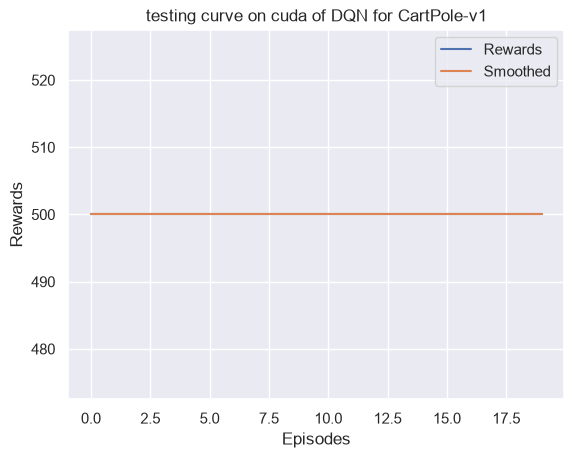

In [6]:
import copy
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
import math
import numpy as np
from tools.utils import seed_env_config, plot_rewards, test
from tools.replay import ReplayBufferQue
from tools.net import MLP


class DQN:
    def __init__(self, cfg):
        self.n_states = cfg.n_states
        self.n_actions = cfg.n_actions  
        self.device = torch.device(cfg.device) 
        self.gamma = cfg.gamma 
        
        # e-greedy策略相关参数
        self.sample_count = 0  
        self.epsilon = cfg.epsilon_start
        self.epsilon_start = cfg.epsilon_start
        self.epsilon_end = cfg.epsilon_end
        self.epsilon_decay = cfg.epsilon_decay

        self.update_count = 0  
        self.batch_size = cfg.batch_size    # 数据批次大小
        self.target_update = cfg.target_update  # 目标网络更新次数
        self.memory = cfg.memory
        
        self.policy_net = cfg.model.to(self.device)
        self.target_net = copy.deepcopy(self.policy_net).to(self.device)
            
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=cfg.lr) 

    def sample_action(self, state):
        ''' 采样动作 '''
        self.sample_count += 1
        # epsilon指数衰减
        self.epsilon = self.epsilon_end + (self.epsilon_start - self.epsilon_end) * \
            math.exp(-1. * self.sample_count / self.epsilon_decay) 
            
        if random.random() > self.epsilon:
            with torch.no_grad():   # 不计算梯度
                # 1-epsilon 概率选Q值最大动作
                state = torch.tensor(state, device=self.device, dtype=torch.float32).unsqueeze(dim=0)
                q_values = self.policy_net(state)
                action = q_values.max(1)[1].item() 
        else:
            # epsilon 概率随机选取
            action = random.randrange(self.n_actions)
        return action

    @torch.no_grad() 
    def predict_action(self, state):
        ''' 预测动作 '''
        state = torch.tensor(state, device=self.device, dtype=torch.float32).unsqueeze(dim=0)
        q_values = self.policy_net(state)
        action = q_values.max(1)[1].item() 
        return action
    
    def load_batch_data(self):
        """ 获取轨迹数据，并转化为张量 """
        state_batch, action_batch, reward_batch, next_state_batch, done_batch = self.memory.sample(self.batch_size)
        
        state_batch = torch.tensor(np.array(state_batch), device=self.device, dtype=torch.float)
        action_batch = torch.tensor(action_batch, device=self.device).unsqueeze(1)  
        reward_batch = torch.tensor(reward_batch, device=self.device, dtype=torch.float)  
        next_state_batch = torch.tensor(np.array(next_state_batch), device=self.device, dtype=torch.float)
        done_batch = torch.tensor(done_batch, device=self.device, dtype=torch.float32)

        return (state_batch, action_batch, reward_batch, next_state_batch, done_batch)


    def update(self):
        if len(self.memory) < self.batch_size: 
            return
        
        self.update_count += 1
        
        # 获取轨迹数据，并转化为张量 
        state_batch, action_batch, reward_batch, next_state_batch, done_batch = self.load_batch_data()
        
        # 预测值：Q(s_i, a_i) 
        q_values = self.policy_net(state_batch).gather(dim=1, index=action_batch) 
        # max( s_(i+1), a )
        next_q_values = self.target_net(next_state_batch).max(1)[0].detach() 
        
        # 目标值：r_i + gamma * max( s_(i+1), a )
        # (1 - done_batch)表示终止动作后续Q值为0
        expected_q_values = reward_batch + self.gamma * next_q_values * (1 - done_batch)
        # 均方误差 计算 预测值与目标值损失
        loss = nn.MSELoss()(q_values, expected_q_values.unsqueeze(1)) 
        
        # 梯度更新
        self.optimizer.zero_grad()  
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), clip_value=1.0)   # 梯度裁剪
        self.optimizer.step() 

        # 更新目标网络参数
        if (self.update_count) % self.target_update == 0:  
            self.target_net.load_state_dict(self.policy_net.state_dict())

def train(cfg, env, agent):
    print("开始训练！")
    print(f'环境：{cfg.env_name}, 算法：{cfg.algo_name}, 设备：{cfg.device}')
    rewards = []  

    for i_ep in range(cfg.train_eps):
        ep_reward = 0  
        state, _ = env.reset()  
        
        for _ in range(cfg.ep_max_steps):
            action = agent.sample_action(state)  
            next_state, reward, terminated, truncated, _ = env.step(action)
            # terminated：环境因为自身逻辑结束，next_q才为0
            # truncated：达到最大步数被强行截断，不是真正的结束，所以可以用网络估算next_q
            # 这是相对于蒙特卡洛回报的优势
            agent.memory.push((state, action, reward, next_state, terminated))  
            state = next_state  
            agent.update()  
            ep_reward += reward  
            
            if terminated or truncated:
                break
            
        rewards.append(ep_reward)
        if (i_ep + 1) % 10 == 0:
            print(f"回合：{i_ep+1}/{cfg.train_eps}，奖励：{ep_reward:.2f}，Epislon：{agent.epsilon:.3f}")
            
    print("完成训练！")
    return {'rewards': rewards}


def DQN_env_agent_config(cfg):
    env = gym.make(cfg.env_name) 

    seed_env_config(cfg, env)

    cfg.model = MLP(cfg.n_states, cfg.n_actions, hidden_dim = cfg.hidden_dim)
    cfg.memory = ReplayBufferQue(cfg.memory_capacity)
    agent = DQN(cfg)
    return env, agent


class DQNConfig:
    def __init__(self) -> None:
        self.algo_name = "DQN"
        self.env_name = "CartPole-v1" 
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.seed = 11
        
        # 训练参数
        self.train_eps = 200
        self.test_eps = 20
        self.ep_max_steps = 500
        
        # DQN核心超参数
        self.gamma = 0.99
        self.epsilon_start = 0.95
        self.epsilon_end = 0.01
        self.epsilon_decay = 2000
        self.lr = 0.0001
        self.memory_capacity = 5000
        self.batch_size = 128
        self.target_update = 64
        self.hidden_dim = 128
        

# 获取参数
cfg = DQNConfig() 
env, agent = DQN_env_agent_config(cfg)
# 训练
res_dic = train(cfg, env, agent)
plot_rewards(res_dic['rewards'], cfg, tag="train")  

# 测试
res_dic = test(cfg, env, agent)
plot_rewards(res_dic['rewards'], cfg, tag="test")  
env.close()